In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [22]:
# # マージ
# # 各ランを読み込み、辞書に追加
# # ランナンバーも追加
# # GRX, GRY, LASX, LASYが-9999も削除

# run_list = [2025, 2026]
# dfs = {}  # 空の辞書を作成

# for run in run_list:
#     file_name = f'run{run}_none.csv'
#     df = pd.read_csv(file_name)

#     xdp=df['GRX']
#     adp=df['GRA']
#     ydp=df['GRY']
#     bdp=df['GRB']
#     GRQ2=df['GRQ2charge']

#     df = df[
#         (xdp!=-9999) & (ydp!=-9999)
#     ]

#     LASX = df['LASX']
#     LASA = df['LASA']
#     LASY = df['LASY']
#     LASB = df['LASB']

#     df = df[
#         (LASX!=-9999) & (LASY!=-9999)
#     ]

#     df.insert(0, 'run', run)

#     # 辞書に格納 (キーをRun番号にする)
#     dfs[run] = df

# # 呼び出すときは dfs[2025] のようにします
# # print(dfs[2025].head())

# # dfsを結合
# # (ここはすでにdfsが作成されている前提です)
# # dfs = {2025: df_2025, 2005: df_2005, ...} 

# # 1. 結合用のリストを作成
# list_of_dfs = []

# # 2. 辞書から一つずつ取り出して処理
# for run_num, df in dfs.items():
#     # 元のデータを壊さないようにコピー
#     df_temp = df.copy()
    
#     # リストに追加
#     list_of_dfs.append(df_temp)

# # 3. 全てを縦に結合 (concat)
# correct = pd.concat(list_of_dfs, ignore_index=True)

In [ ]:
correct = pd.read_csv("Pb_labeled.csv")

In [24]:
GRQ2_track = correct['GRQ2charge']

TOT=correct['LASTOT']
Lx=correct['LASX']
GRtiming=correct['GRQ2timing']
LAStiming=correct['LASQ1timing']
TDiff=LAStiming-GRtiming



In [25]:
PID_gated = correct[
    (GRQ2_track > 213.276 - 21.194 * 5) & (GRQ2_track < 213.276 + 21.194 * 5) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>140) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<170)
]

TOT_alpha=PID_gated['LASTOT']
Lx_alpha=PID_gated['LASX']
GRtiming_alpha=PID_gated['GRQ2timing']
LAStiming_alpha=PID_gated['LASQ1timing']
TDiff_alpha=LAStiming_alpha-GRtiming_alpha

In [26]:
PID_gated

,run,iEve,GRX,GRA,GRY,GRB,GRQ2timing,GRQ2charge,LASX,LASA,LASY,LASB,LASQ1timing,LASTOT
2,2025,79,76.6026,0.007484,18.89030,-0.002013,146236.00,226.542,181.97800,0.077720,-206.6000,0.268428,146322.0,151.626
3,2025,85,254.6680,0.048382,-21.43400,0.005113,280165.00,202.365,153.15500,0.141902,38.8580,0.009935,280248.0,145.132
7,2025,242,441.3170,-0.010276,-7.12638,0.000953,21340.70,211.313,366.13200,0.018993,-43.2924,-0.020411,21075.1,140.714
11,2025,402,-34.5970,-0.031650,-12.32830,0.002291,6889.75,191.201,145.40100,0.008798,39.4162,0.015231,6977.1,148.355
13,2025,590,58.1263,0.012181,-11.62530,0.003453,178614.00,230.683,1.00431,0.176757,70.5937,0.038654,178640.0,149.979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114479,2026,5946214,-129.0030,-0.028019,-17.97280,0.003862,429737.00,189.351,-311.79500,0.129594,14.0309,0.006555,430059.0,176.410
114483,2026,5946319,186.1630,0.010301,19.23750,-0.004590,219711.00,218.169,-351.13400,-0.177895,-28.1351,-0.000423,220164.0,181.005
114488,2026,5946355,-78.8341,0.011152,-30.96540,0.006082,316178.00,232.526,64.82520,0.045539,88.6055,0.057665,316260.0,154.524
114495,2026,5946580,-222.1470,-0.033318,-23.46050,0.003556,51493.10,234.663,213.61600,-0.066629,-15.4555,-0.013431,51403.9,151.377


In [27]:
#Tp, Ta制限

# --- 物理量の計算 ---
GRX = PID_gated['GRX']
LASX = PID_gated['LASX']
LASA = PID_gated['LASA']

# Tp, Tαの計算
Tp = (((GRX * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
LASX_f = LASA * (-2.57 * Tp + 1274.57) + LASX
T_alpha_f = 0.02746 * LASX_f + 63.804

PID_gated = PID_gated[
    (Tp > 305) & (Tp < 330) & (T_alpha_f > 55) & (T_alpha_f < 80)
]

Text(0, 0.5, 'counts')

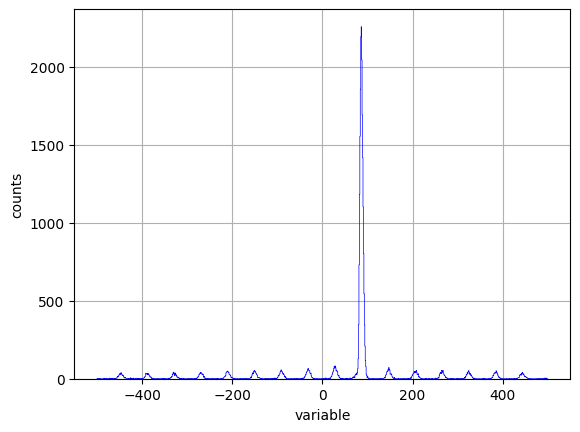

In [28]:
#input
####################################################
#variables
variable=TDiff_alpha
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_11885/4017365459.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  true = PID_gated[


Text(0, 0.5, 'counts')

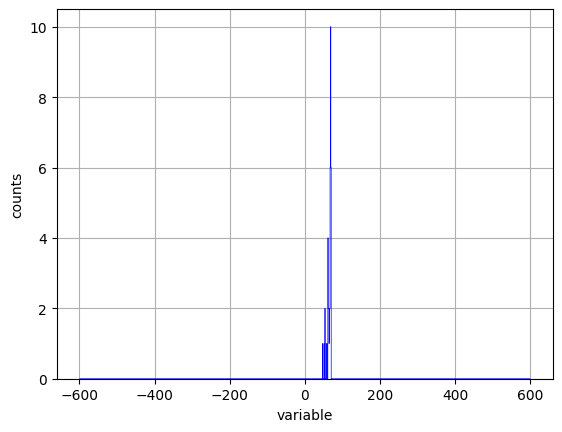

In [29]:
true = PID_gated[
    (TDiff_alpha >= 47) & (TDiff_alpha < 70)
]
#input
####################################################
#variables
variable = true['LASQ1timing'] - true['GRQ2timing']
#hist range
range_min=-600
range_max=600
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

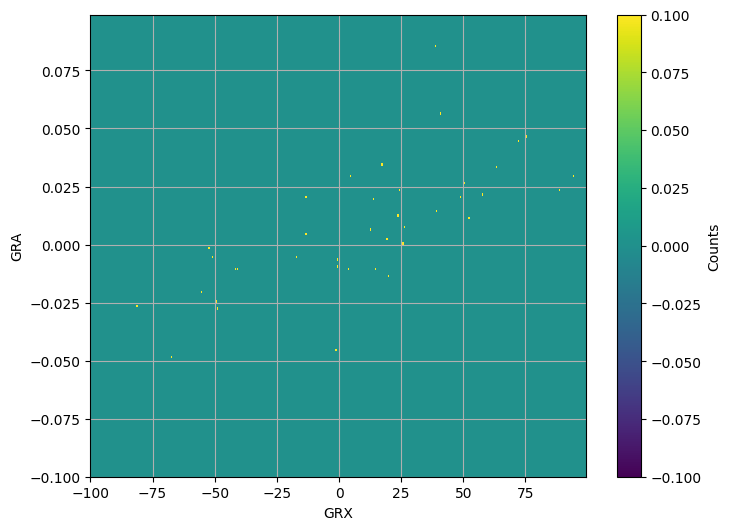

In [30]:
from matplotlib.colors import Normalize
#input
####################################################
#variables
# x_axis_variable = PID_gated['LASY']
# y_axis_variable = PID_gated['LASB']
x_axis_variable = true['LASY']
y_axis_variable = true['LASB']
# hist range
x_axis_range_min = -100
x_axis_range_max = 100
y_axis_range_min = -0.1
y_axis_range_max = 0.1
# bin width
x_bin_width=0.5
y_bin_width=0.001
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins = bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('GRX')
ax.set_ylabel('GRA')
# ax.set_xlim(-400, 600)
ax.grid()

In [31]:
# true coincidenceのヒストグラム
#コインシデンスゲート


# ヒストグラムの設定
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- 物理量の計算 ---
GRX_acc = true['GRX']
LASX_acc = true['LASX']
LASA_acc = true['LASA']

# Tp, Tαの計算
Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
# Variable (S_alpha)
variable = 392 - Tp_acc - T_alpha_acc_f

# --- ヒストグラム作成 (カウントのみ取得) ---
counts2, _ = np.histogram(variable, bins=bins)
    
# リストに追加
hist_list2 = []
hist_list2.append(counts2)

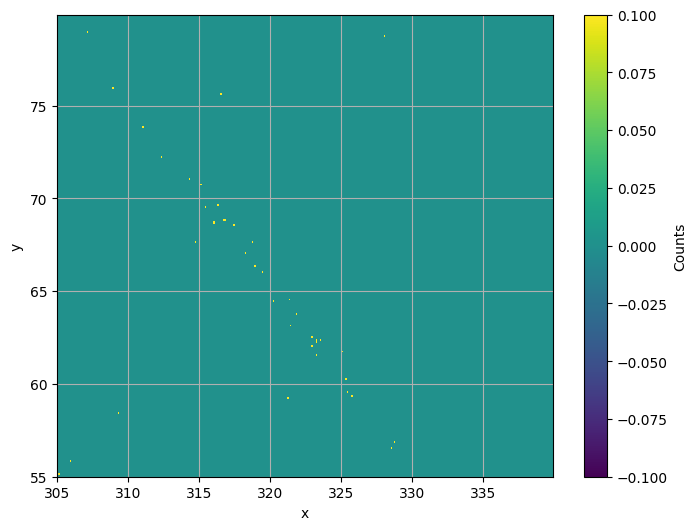

In [32]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
# x_axis_variable = PID_gated['LASY']
# y_axis_variable = PID_gated['LASB']
x_axis_variable = Tp_acc
y_axis_variable = T_alpha_acc_f
# hist range
x_axis_range_min = 305
x_axis_range_max = 340
y_axis_range_min = 55
y_axis_range_max = 80
# bin width
x_bin_width = 0.1
y_bin_width = 0.1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins = bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('x')
ax.set_ylabel('y')
# ax.set_xlim(-400, 600)
ax.grid()

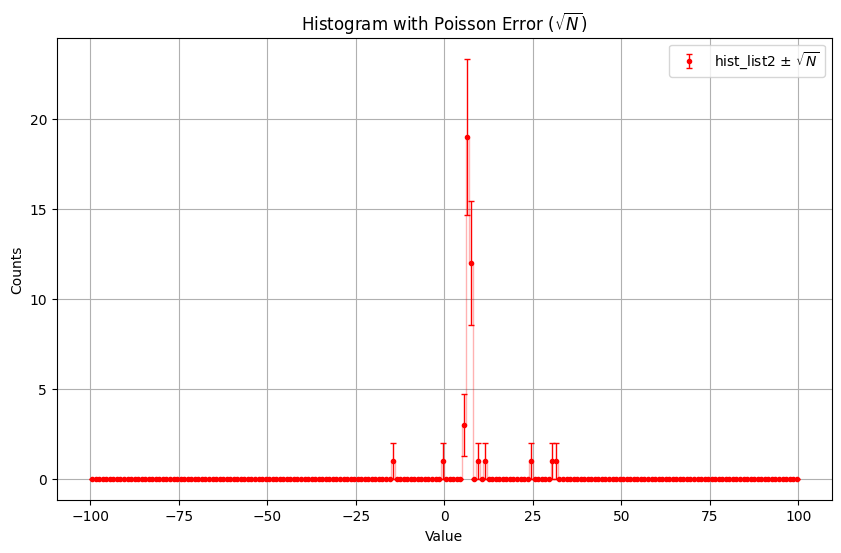

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- 事前準備 (hist_list2 と bins は作成済みと仮定) ---
# hist_list2: ヒストグラムのカウント数配列 (1次元)
# bins: ビンの境界配列
# ヒストグラムの設定
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# ビンの中心を計算
bin_centers = (bins[:-1] + bins[1:]) / 2

# もし hist_list2 がリストの中に入っている場合 ([array(...)]) は取り出す
# hist_list2 = hist_list2[0] 

# --- 1. 誤差の計算 (ルートN) ---
# カウント数の平方根を計算
error2 = np.sqrt(hist_list2[0])

# --- 2. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# エラーバー付きでプロット
# fmt='o' で点として描画し、エラーバーを付けます
ax.errorbar(bin_centers, hist_list2[0], yerr=error2, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='red',
            label='hist_list2 ± $\sqrt{N}$')

# 形状を見やすくするために、薄くステップ状の線も重ねて描くのが一般的です
ax.step(bin_centers, hist_list2[0], where='mid', color='red', alpha=0.3, linewidth=1)

ax.set_xlabel('Value')
ax.set_ylabel('Counts')
ax.set_title('Histogram with Poisson Error ($\sqrt{N}$)')
ax.legend()
ax.grid(True)

plt.show()

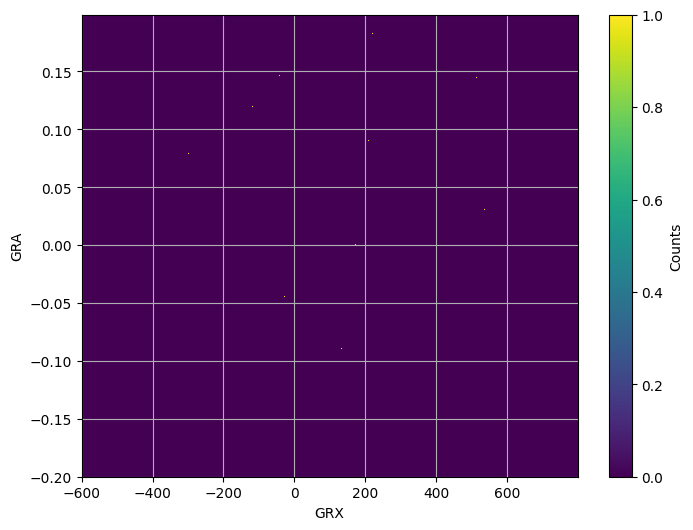

In [34]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable = true['LASX']
y_axis_variable = true['LASA']
# hist range
x_axis_range_min = -600
x_axis_range_max = 800
y_axis_range_min = -0.2
y_axis_range_max = 0.2
# bin width
x_bin_width=1
y_bin_width=0.001
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins = bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 1)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('GRX')
ax.set_ylabel('GRA')
# ax.set_xlim(200, 500)
# ax.set_xlim(-300, 300)
ax.grid()

Text(0, 0.5, 'counts')

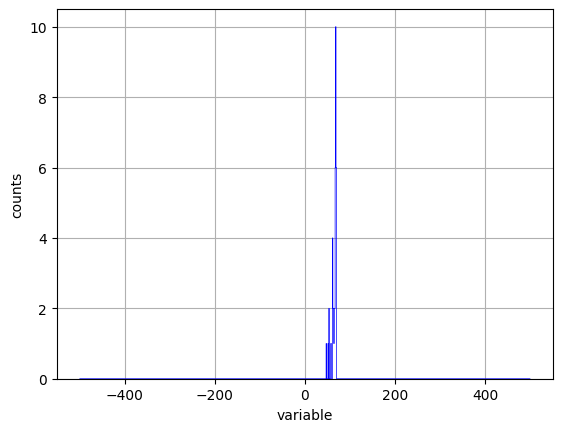

In [35]:
#アルファゲートかけてコインシデンスとる
#綺麗にアクシデンタル減らせたのを確認

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable = true['LASQ1timing'] - true['GRQ2timing']
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_11885/2071445912.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_11885/2071445912.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_11885/2071445912.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_11885/2071445912.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_11885/2071445912.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_11885/2071445912.py:64: UserWarning:

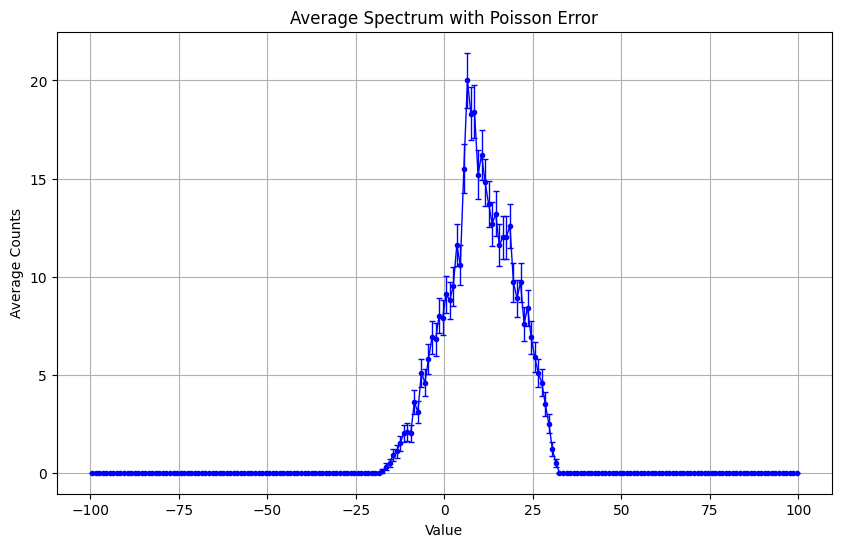

In [36]:
# アクシデンタルの誤差を再考
# 誤差棒の大きさはfrac{\sqrtN}{10}です

# -250から50まで
# --- 1. 設定パラメータ ---
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = -250      # 開始位置
end_tdiff = 50         # 終了位置

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# ヒストグラムデータを格納するリスト
hist_list = []

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)



#110から410
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = 110      # 開始位置
end_tdiff = 410         # 終了位置

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)



# --- 3. 平均と誤差の計算 ---

# リストをNumPy配列（行列）に変換
# 行: 各TDiffウィンドウ, 列: 各ビン
hist_matrix = np.array(hist_list)

# # 平均スペクトル
mean_spectrum = np.mean(hist_matrix, axis=0)
summed_spectrum = np.sum(hist_matrix, axis=0)
error = np.sqrt(summed_spectrum) / 10

# --- 4. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
                fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
                label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
# for i in range(10):
#     ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.5, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over 10 Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")



ax.set_xlabel('Value')
ax.set_ylabel('Average Counts')
ax.set_title('Average Spectrum with Poisson Error')
ax.grid(True)
# ax.legend()

plt.show()

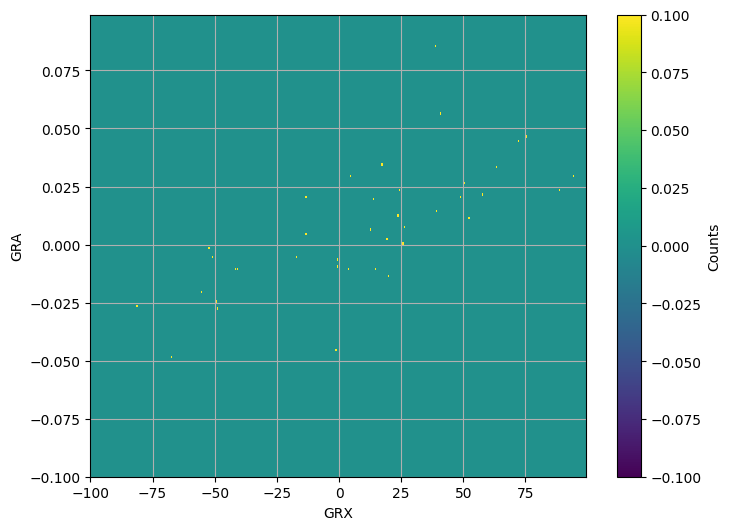

In [ ]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
# x_axis_variable = PID_gated['LASY']
# y_axis_variable = PID_gated['LASB']
x_axis_variable = true['LASY']
y_axis_variable = true['LASB']
# hist range
x_axis_range_min = -100
x_axis_range_max = 100
y_axis_range_min = -0.1
y_axis_range_max = 0.1
# bin width
x_bin_width=0.5
y_bin_width=0.001
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins = bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('GRX')
ax.set_ylabel('GRA')
# ax.set_xlim(-400, 600)
ax.grid()

In [ ]:
# --- 1. 設定パラメータ ---
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = -250      # 開始位置
end_tdiff = 50         # 終了位置

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

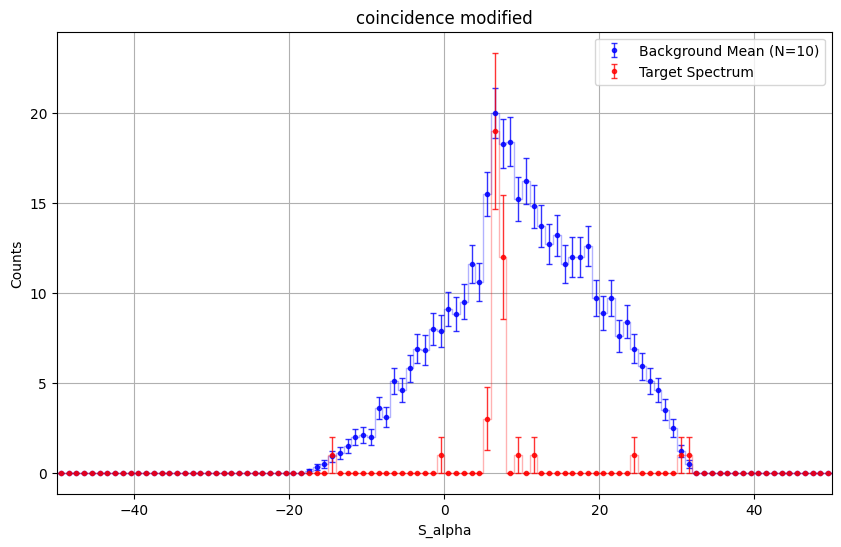

In [ ]:
#便宜的に
N_samples = 10

# --- 3. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# (A) hist_list1 (BG Mean) の描画
ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='blue', alpha=0.8,
            label=f'Background Mean (N={N_samples})')
# 視認用ライン
ax.step(bin_centers, mean_spectrum, where='mid', color='blue', alpha=0.3, linewidth=1)


# (B) hist_list2 (Target) の描画
ax.errorbar(bin_centers, hist_list2[0], yerr=error2, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='red', alpha=0.8,
            label='Target Spectrum')
# 視認用ライン
ax.step(bin_centers, hist_list2[0], where='mid', color='red', alpha=0.3, linewidth=1)


# グラフの設定
ax.set_xlabel('S_alpha')
ax.set_ylabel('Counts')
ax.set_title('coincidence modified')
ax.set_xlim(-50, 50)
ax.legend()
ax.grid(True)

plt.show()